In [2]:
%matplotlib widget

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches
import ipywidgets as widgets
from matplotlib.widgets import Button, Slider

import numpy as np
import os
import cv2
import sys
sys.path.append('..')

from PIL import Image
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_visualization import *

import distinctipy

In [3]:
# Configuration
folder_path = "../output_3d"  # Folder containing hand pose data
num_keypoints = 21  # Number of keypoints per hand (21 for each hand)
num_cameras = len(cam_names)  # Number of cameras in your setup
data_collection = 'cha1'  # Change to your data collection
hand_sides = ['left', 'right']  # We'll handle both hands

# File paths
hand_poses_2d_file = os.path.join(folder_path, data_collection, 'hand_poses_2d.npz')
#output_file = os.path.join(folder_path, data_collection, 'hand_poses_2d_corrected.npz')

cam_names = []  # List to store camera names

# Load hand poses
if os.path.exists(hand_poses_2d_file):
    data = np.load(hand_poses_2d_file, allow_pickle=True)
    hand_poses_2d = data['poses_2d'].item()  # This is likely a dictionary
    print(f"Loaded hand poses from {hand_poses_2d_file}")
    
    # Determine number of frames from the data
    for cam_name in hand_poses_2d.keys():
        cam_names.append(cam_name)
        num_frames = len(hand_poses_2d[cam_name])
        print(f"Found {num_frames} frames for camera {cam_name}")
else:
    print(f"Error: Hand poses file not found at {hand_poses_2d_file}")
    num_frames = 0
    hand_poses_2d = {}

# Set up video paths
video_dir = f'../inputs/{data_collection}'
video_paths = {}
for cam_name in cam_names:
    for file in os.listdir(video_dir):
        if file.startswith(f"{cam_name}_") and file.endswith('.MP4'):
            video_paths[cam_name] = os.path.join(video_dir, file)
            break

# Initial state
frame_idx = 0  # start frame
hand_side_idx = 0  # 0 for left, 1 for right
obj_id = 0  # Default object ID
keypoint_idx = 0  # start with first keypoint
cam_name = cam_names[0] if cam_names else "gopro10"  # start camera
keypoint_list = list(range(num_keypoints))
advance = 0  # Default advance step (move to next keypoint after editing)
hand_side = 'left' # Default hand side
hand_side_idx = 0  # 0 for left hand, 1 for right hand
frame_stride = 30 # One frame per second

Loaded hand poses from ../output_3d/cha1/hand_poses_2d.npz
Found 300 frames for camera gopro10
Found 300 frames for camera gopro11
Found 300 frames for camera gopro12
Found 300 frames for camera gopro5
Found 300 frames for camera gopro6
Found 300 frames for camera gopro7
Found 300 frames for camera gopro8
Found 300 frames for camera gopro9


Dropdown(description='Camera:', index=6, options=('gopro10', 'gopro11', 'gopro12', 'gopro5', 'gopro6', 'gopro7…

Dropdown(description='Advance:', index=1, options=(-1, 0, 1), value=0)

Dropdown(description='Hand Side:', options=('left', 'right'), value='left')

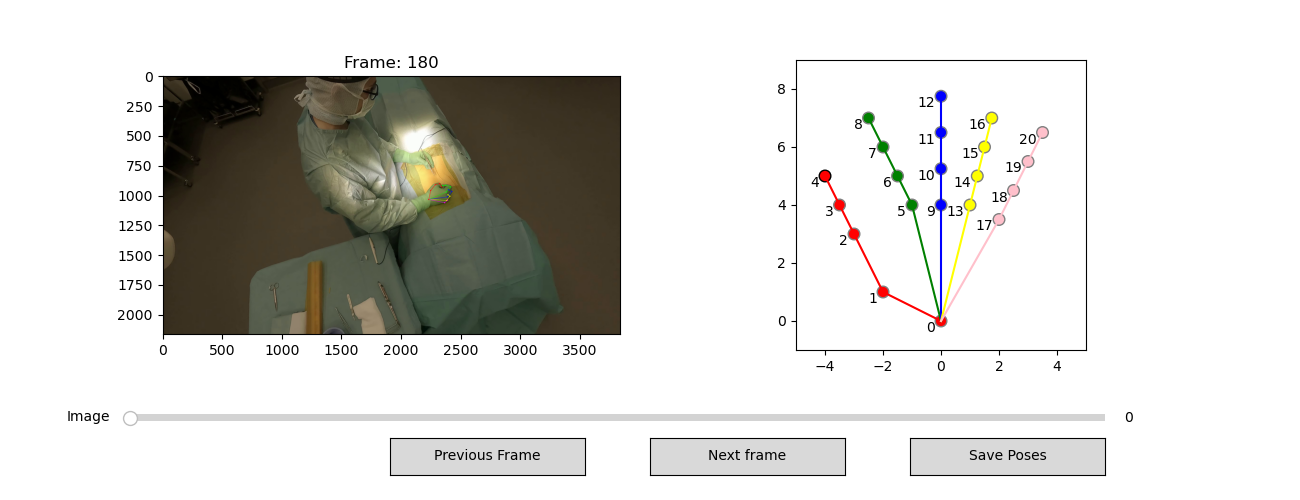

KeyError: -1

KeyError: -1

KeyError: -1

In [8]:
# Load the given frame
video = cv2.VideoCapture(video_paths[cam_name])  # Replace with your image path
if not video.isOpened():
    raise FileNotFoundError(f"Cannot open video file: {video_paths[cam_name]}")

# Set the video to the nth frame
video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

# Read the frame
success, frame = video.read()
if not success:
    raise ValueError(f"Frame {frame_idx} does not exist in the video.")
frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) 

frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plt.subplots_adjust(bottom=0.3) 
ax1.set_title("Frame: {}".format(frame_idx))
img_display = ax1.imshow(frame, aspect='equal')

actor_keypoint_map = {}
keypoint_actor_map = {}

last_pos = None

def draw_hand_keypoints_ref(ax):
    global plt
    global last_pos
    def draw_point(ax, x, y, label, color):
        global last_pos
        if last_pos is not None:
            ax.plot([last_pos[0], x],[last_pos[1], y],color=color)
        radius=0.2
        edgecolor='gray'
        if keypoint_idx==label:
            edgecolor = 'black'
        circle = patches.Circle((x,y), radius=radius, facecolor=color, edgecolor=edgecolor,picker=True)
        ax.add_patch(circle)
        ax.text(x - radius, y, str(label), fontsize=10, ha='right', va='top')
        actor_keypoint_map[circle] = label
        keypoint_actor_map[label] = circle
        last_pos = (x,y)

    draw_point(ax, 0, 0, 0, 'red')
    draw_point(ax, -2, 1, 1, 'red')
    draw_point(ax, -3, 3, 2, 'red')
    draw_point(ax, -3.5, 4, 3, 'red')
    draw_point(ax, -4, 5, 4, 'red')
    last_pos = (0,0)
    draw_point(ax, -1, 4, 5, 'green')
    draw_point(ax, -1.5, 5, 6, 'green')
    draw_point(ax, -2, 6, 7, 'green')
    draw_point(ax, -2.5, 7, 8, 'green')
    last_pos = (0,0)
    draw_point(ax, 0, 4, 9, 'blue')
    draw_point(ax, 0, 5.25, 10, 'blue')
    draw_point(ax, 0, 6.5, 11, 'blue')
    draw_point(ax, 0, 7.75, 12, 'blue')
    last_pos = (0,0)
    draw_point(ax, 1, 4, 13, 'yellow')
    draw_point(ax, 1.25, 5, 14, 'yellow')
    draw_point(ax, 1.5, 6, 15, 'yellow')
    draw_point(ax, 1.75, 7, 16, 'yellow')
    last_pos = (0,0)
    draw_point(ax, 2, 3.5, 17, 'pink')
    draw_point(ax, 2.5, 4.5, 18, 'pink')
    draw_point(ax, 3, 5.5, 19, 'pink')
    draw_point(ax, 3.5, 6.5, 20, 'pink')
    ax.set_xlim(-5,5)
    ax.set_ylim(-1,9)
    ax.set_aspect('equal')


#image = mpimg.imread('hand_keypoints_reference.png')
#ax2.imshow(image, aspect='auto')
draw_hand_keypoints_ref(ax2)
color_map = distinctipy.get_colors(num_keypoints)

plotted_points = []

def update_selected_keypoint(next):
    global actor_keypoint_map
    global keypoint_actor_map
    global keypoint_idx
    keypoint_actor_map[keypoint_idx].set_edgecolor('gray')
    keypoint_actor_map[next].set_edgecolor('black')
    keypoint_idx = next

def onpick(event):
    new_keypoint_idx = actor_keypoint_map[event.artist]
    if new_keypoint_idx is None:
        return
    update_selected_keypoint(new_keypoint_idx)

# Function that will be called when you click on the image
def onclick(event):
    global frame_idx
    global keypoint_idx
    global plotted_points
    toolbar = getattr(event.canvas, "toolbar", None)
    if event.button == 2 and toolbar:
        toolbar.pan()
        return
    if toolbar and toolbar.mode:
        return
    # Check if the click is within the axes
    if event.inaxes == ax1 and keypoint_idx != -1:
        x, y = int(event.xdata), int(event.ydata)
        #if advance == 0 and plotted_points != []:
        #    plotted_points.pop().remove()
        #pt, = ax1.plot(x, y, 'x', color=color_map[keypoint_idx], ms=10)
        #plotted_points.append(pt)
        score = 1
        if event.button == 3:
            score = 0
        hand_poses_2d[cam_name][frame_idx][hand_side_idx].keypoints[0, keypoint_idx] = [x, y]
        hand_poses_2d[cam_name][frame_idx][hand_side_idx].keypoint_scores[0, keypoint_idx] = score
        print(f'Clicked at: (x={x}, y={y}). {keypoint_idx} updated')
        submit_points_()
        if advance != 0:
            keypoint_idx_new = keypoint_idx + advance
            if keypoint_idx >= 0 and keypoint_idx <= 20:
                update_selected_keypoint(keypoint_idx_new)

def onkeypress(event):
    if event.key == 'left':
        previous_frame(event)
    if event.key == 'right':
        next_frame(event)

def submit_points_():
    global frame_idx
    global keypoint_idx
    global frame, video, img_display
    global plotted_points

    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
    #ax1.clear()
    for artist in plotted_points:
        artist.remove()
    plotted_points.clear()
    fig.canvas.draw()
    img_display = ax1.imshow(frame, aspect='equal')
    ax1.set_title("Frame: {}".format(frame_idx))
    
def next_frame(event):
    global frame_idx, frame_stride
    global frame, video, img_display
    if frame_idx < num_frames - frame_stride:
        frame_idx += frame_stride
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        # Read the frame
        success, frame = video.read()
        if not success:
            raise ValueError(f"Frame {frame_idx} for cam {cam_name} does not exist in the video.")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
        img_display.set_data(frame)  # Update the image displayed
        ax1.set_title("Frame: {}".format(frame_idx))

    
def previous_frame(event):
    global frame_idx, frame_stride
    global frame, video, img_display
    if frame_idx >= frame_stride:
        frame_idx -= frame_stride
        video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

        # Read the frame
        success, frame = video.read()
        if not success:
            raise ValueError(f"Frame {frame_idx} does not exist in the video.")
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
        img_display.set_data(frame)  # Update the image displayed
        ax1.set_title("Frame: {}".format(frame_idx))

     
    
def update_image(val):
    global frame_idx, frame, video
    frame_idx = int(val)
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
    img_display.set_data(frame)  # Update the image displayed
    ax1.set_title("Frame: {}".format(frame_idx))

#def dropdown_change(change):
#    global keypoint_idx, keypoint_list
#    keypoint_idx = change['new']
#    print(f'Keypoint idx changed to: {keypoint_idx}')

def dropdown2_change(change):
    global cam_name, cam_names, video, frame, frame_idx
    cam_name = change['new']

    # Load the given frame
    video = cv2.VideoCapture(video_paths[cam_name])  # Replace with your image path
    if not video.isOpened():
            raise FileNotFoundError(f"Cannot open video file: {video_paths[cam_name]}")

    # Set the video to the nth frame
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
    img_display.set_data(frame)
    print(f'Camera changed to: {cam_name}')

def dropdown3_change(change):
    global advance
    advance = change['new']
    print(f"Advance step changed to: {advance}")

def dropdown4_change(change):
    global hand_side_idx, hand_poses_2d
    hand_side = change['new']
    hand_side_idx = hand_sides.index(hand_side)
    video.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    # Read the frame
    success, frame = video.read()
    if not success:
        raise ValueError(f"Frame {frame_idx} does not exist in the video.")
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    frame = draw_pose(frame, hand_poses_2d[cam_name][frame_idx][hand_side_idx], pose_type='hand', return_frame=True)
    img_display.set_data(frame)  # Update the image displayed
    print(f"Hand side changed to: {hand_side}")

def save_poses(event):
    np.savez(hand_poses_2d_file, poses_2d=hand_poses_2d)


# Create a button to switch the color
#axsubmit = plt.axes([0.1, 0.05, 0.15, 0.075])
#btn_submit = Button(axsubmit, 'Update Pose')
#btn_submit.on_clicked(submit_points)
axprev = plt.axes([0.3, 0.05, 0.15, 0.075])
btn_prev = Button(axprev, 'Previous Frame')
btn_prev.on_clicked(previous_frame)
axnext = plt.axes([0.5, 0.05, 0.15, 0.075])
btn_next = Button(axnext, 'Next frame')
btn_next.on_clicked(next_frame)
axsave = plt.axes([0.7, 0.05, 0.15, 0.075])
btn_save = Button(axsave, 'Save Poses')
btn_save.on_clicked(save_poses)

axslider = plt.axes([0.1, 0.15, 0.75, 0.03], facecolor='lightgoldenrodyellow')
slider = Slider(axslider, 'Image', 0, num_frames - 1, valinit=0, valstep=1)
slider.on_changed(update_image)

#dropdown = widgets.Dropdown(
#    options=keypoint_list,
#    value=keypoint_list[0],
#    description='Keypoint:',
#    disabled=False,
#)
#dropdown.observe(dropdown_change, names='value')
#display(dropdown)
dropdown2 = widgets.Dropdown(
    options=cam_names,
    value=cam_name,
    description='Camera:',
    disabled=False,
)
dropdown2.observe(dropdown2_change, names='value')
display(dropdown2)
dropdown3 = widgets.Dropdown(
    options=[-1, 0, 1],
    value=advance,
    description='Advance:',
    disabled=False,
)
dropdown3.observe(dropdown3_change, names='value')
display(dropdown3)
dropdown4 = widgets.Dropdown(
    options=hand_sides,
    value=hand_side,
    description='Hand Side:',
    disabled=False,
)
dropdown4.observe(dropdown4_change, names='value')
display(dropdown4)

# Connect the click event to the function
fig.canvas.mpl_connect('button_press_event', onclick)
fig.canvas.mpl_connect('key_press_event', onkeypress)
fig.canvas.mpl_connect('pick_event', onpick)

# Display the plot inline
plt.show()

In [25]:
# Release resources when done
if video is not None:
    video.release()